In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv("/kaggle/input/datasets/mohithsairamreddy/salary-data/Salary_Data.csv")

In [4]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [5]:
df.shape

(6704, 6)

In [6]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [7]:
#Deleting null rows since less null. Alt: Imputation with mean, mode or median.
df = df.dropna()

In [8]:
#x must be a dataframe(2d array) for scikit-learn lib
x = df[['Years of Experience']]
#y is a series(1d array)
y = df['Salary']

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)
print(f"Training set size: {x_train.shape[0]} rows")
print(f"Test set size: {x_test.shape[0]} rows")

Training set size: 5358 rows
Test set size: 1340 rows


In [10]:
#Initialise the model(function)
mdl = LinearRegression()

#Train model using training set
#Model finds the optimal slope and intercept such that error is minimized
mdl.fit(x_train, y_train)

print(f"Intercept(c): {mdl.intercept_:.2f}")
print(f"Coefficient(m): {mdl.coef_[0]:.2f}")


Intercept(c): 58196.21
Coefficient(m): 7072.86


In [11]:
y_pred = mdl.predict(x_test)
#y_test = actual value, y_pred = predicted value
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:{mse:.2f}")
print(f"R2: {r2:.2f}")

MSE:982050061.92
R2: 0.66


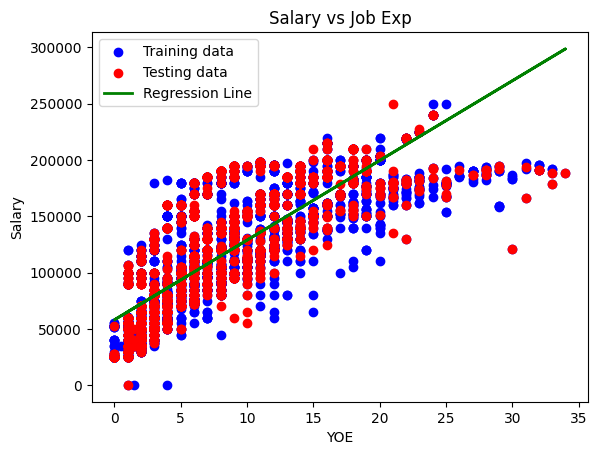

In [13]:
plt.scatter(x_train, y_train, color='blue',label='Training data')
plt.scatter(x_test, y_test, color='red',label='Testing data')
plt.plot(x,mdl.predict(x),color='green',linewidth=2,label='Regression Line')

plt.title('Salary vs Job Exp')
plt.xlabel('YOE')
plt.ylabel('Salary')
plt.legend()

plt.show()